## This file retrieves a large sample dataset that I spent money to create
Then we use that testdata to evaluate the performance of the RAG pipelines 
but instead of using a smart model like GPT-4, I am going to use gpt-oss120b running on my laptop.

In [1]:
import getpass
import os


def set_api_key(key_name: str) -> None:
    """
    Securely set an environment variable if it doesn't already exist.
    Prompts the user for input using a password-style hidden input.
    
    Args:
        key_name (str): Name of the environment variable to set (e.g., "OPENAI_API_KEY")
    """
    if not os.environ.get(key_name):
        os.environ[key_name] = getpass.getpass(f"{key_name}: ")

# Example usage:
set_api_key("OPENAI_API_KEY")

In [2]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

In [3]:
from langchain_openai import ChatOpenAI
from ragas.llms import LangchainLLMWrapper
from langchain_openai import OpenAIEmbeddings
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from sqlalchemy import true
import pandas as pd

  # LM Studio uses OpenAI-compatible API format
generator_llm = ChatOpenAI(
      base_url="http://192.168.1.157:1234/v1",  # Replace with your server 
      api_key="lmstudio",  # LM Studio doesn't require real API key
      model="openai/gpt-oss-20b",  # Optional: specify model name
      temperature=0.1
    #   verbose=True 
  )

try:
  response = generator_llm.invoke("Test message")
  print(response)
except Exception as e:
  print(f"Error details: {e}")
  
  # Wrap for RAGAS
ragas_llm = LangchainLLMWrapper(generator_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

content='Hello! How can I help you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 69, 'total_tokens': 93, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'openai/gpt-oss-20b', 'finish_reason': 'stop', 'logprobs': None} id='run--19edae0b-6788-46de-9093-8bf8a355f400-0' usage_metadata={'input_tokens': 69, 'output_tokens': 24, 'total_tokens': 93, 'input_token_details': {}, 'output_token_details': {}}


In [4]:
# Retrieve the dataset (it is already a pandas df when I read it)
synthesized_dataset = pd.read_json("synthesized_dataset.json", lines=True)

In [5]:
# Naive split
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

3122

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [7]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data",
    embedding=embeddings,
)

In [8]:
_ = vector_store.add_documents(documents=split_documents)

In [9]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [10]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [11]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [12]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = generator_llm.invoke(messages)
  return {"response" : response.content}

In [13]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

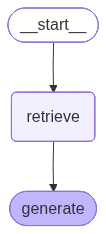

In [14]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [15]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'I’m sorry, but I don’t have enough information from the provided context to answer that question.'

In [16]:
graph.invoke({"question":"How do people use AI?"})["response"]

'People mainly use AI to help with **workplace tasks**—for example, automating routine work or generating content. This is described as the most common way that generative AI is applied in professional settings.'

In [17]:
synthesized_dataset

,user_input,reference_contexts,reference,synthesizer_name
0,What role does Artificial Intelligence play in...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
1,What role does Artificial Intelligence play in...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
2,Whaat wuz the reported prevelance of ChatGPT u...,[Introduction ChatGPT launched in November 202...,Bick et al. (2024) report that 28% of US adult...,single_hop_specifc_query_synthesizer
3,Wut did Pew Reserch Center do?,[Introduction ChatGPT launched in November 202...,Pew Research Center measured self-reported ado...,single_hop_specifc_query_synthesizer
4,What is a Large Language Model as it relates t...,[Introduction ChatGPT launched in November 202...,ChatGPT is based on a Large Language Model (LL...,single_hop_specifc_query_synthesizer
...,...,...,...,...
65,how chatgpt help work people in different jobs...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,users in high paid professional and technical ...,multi_hop_abstract_query_synthesizer
66,How does the variation in work-related ChatGPT...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,Variation in work-related ChatGPT usage by occ...,multi_hop_abstract_query_synthesizer
67,how chatgpt usage different for work between c...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,chatgpt used more for work by people in comput...,multi_hop_abstract_query_synthesizer
68,how chatgpt get used by people and what jobs u...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"chatgpt got real big fast, with 700 million us...",multi_hop_abstract_query_synthesizer


In [18]:
type(synthesized_dataset)

pandas.core.frame.DataFrame

In [19]:



synthesized_dataset['response'] = None
synthesized_dataset['retrieved_contexts'] = None
for idx, row in synthesized_dataset.iterrows():
    response = graph.invoke({"question": row['user_input']})
    synthesized_dataset.at[idx, 'response'] = response["response"]
    synthesized_dataset.at[idx, 'retrieved_contexts'] = [context.page_content for context in response["context"]]

In [20]:
from ragas import EvaluationDataset
evaluation_dataset = EvaluationDataset.from_pandas(synthesized_dataset)

In [21]:
evaluator_llm = LangchainLLMWrapper(generator_llm)

In [ ]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
result

In [33]:
result

{'context_recall': 0.0768, 'faithfulness': 0.3466, 'factual_correctness': 0.3350, 'answer_relevancy': 0.7125, 'context_entity_recall': 0.1335, 'noise_sensitivity_relevant': nan}

In [25]:
set_api_key("COHERE_API_KEY")

In [26]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=30)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_new_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [27]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [29]:
class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

In [30]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'I’m sorry, but the provided context does not contain any information about different kinds of loans.'

In [32]:
import copy
rerank_dataset = copy.deepcopy(synthesized_dataset)
# synthesized_dataset['response'] = None
# synthesized_dataset['retrieved_contexts'] = None
for idx, row in rerank_dataset.iterrows():
    response = adjusted_graph.invoke({"question": row['user_input']})
    rerank_dataset.at[idx, 'response'] = response["response"]
    rerank_dataset.at[idx, 'retrieved_contexts'] = [context.page_content for context in response["context"]]

In [34]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset)

In [ ]:
custom_run_config = RunConfig(timeout=180)

rerank_result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)


In [36]:
rerank_result

{'context_recall': 0.5623, 'faithfulness': 0.6564, 'factual_correctness': nan, 'answer_relevancy': 0.9185, 'context_entity_recall': 0.4649, 'noise_sensitivity_relevant': nan}